# **MAT 4373: Project** </br> L1 vs. L2 regularization
Here we will be investigating the behaviour of regularization (L1 and L2 regularization) in a high dimensional environment, observing both correlated and uncorrelated datasets. We want to see how regularization performs under various conditions.

### **Dataset: A high-dimensional Gaussian design**

We consider the high-dimensional regime where the number of features exceeds the number of observations (d > n).

We generate data using the same sparse linear model:

y = Xw* + ε

but with d > n, making the problem underdetermined.

In this setting, the design matrix X is not full rank, and the ordinary least squares solution is not unique.

**Goal**  
We study:
- the necessity of regularization in high-dimensional settings,
- why Ridge yields a unique solution,
- why Lasso produces sparse solutions,
- how prediction accuracy and support recovery behave when d > n.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, recall_score
from sklearn.model_selection import train_test_split
from data_generation import generate_sparse_linear_data
from data_generation import generate_correlated_sparse_linear_data
from sklearn.metrics import mean_squared_error, recall_score, f1_score

#### **Experiment 1: Effects of Dimension**

We observe how a high dimensional environment affects our model, more precisely why regularization is a useful tool in high dimensional settings. We will plot the MSE to the number of dimensions to observe this effect, all other variables will remain unchanged. We will split our experiment into 2 comparisons, independent datasets (rho=0) and correlated datasets (rho=0.7).


c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.324e-02, tolerance: 1.560e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.669e-02, tolerance: 1.560e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

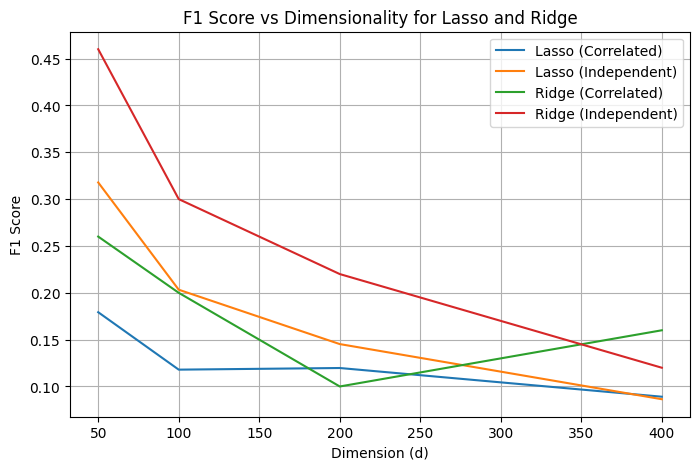

In [4]:
coefficients = [50, 100, 200, 400]
num_trials = 10

results = {
    "d": [],
    "lasso_f1_correlated": [],
    "lasso_f1_uncorrelated": [],
    "ridge_f1_correlated": [],
    "ridge_f1_uncorrelated": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for d in coefficients:
    lasso_f1s_corr = []
    lasso_f1s= []
    ridge_f1s_corr = []
    ridge_f1s = []
    for seed in range(num_trials):

        X, y, w_true, support = generate_sparse_linear_data(n=30, d=d, s=5, sigma=1.5, signal=1.0, random_seeds=seed)
    
        X_corr,y_corr,w_true_corr,support_corr,Sigma_corr=generate_correlated_sparse_linear_data(n=30, d=d, s=5, sigma=1.5, signal=1.0, rho=0.99, random_seeds=seed)

        true_support = np.zeros(len(w_true), dtype=int)
        true_support[support] = 1

        true_support_corr = np.zeros(len(w_true_corr), dtype=int)
        true_support_corr[support_corr] = 1


        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed
        )
    
        X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas = np.logspace(-4, 1, 50))
        lasso.fit(X_train, y_train)
        lasso_support = (lasso.coef_ != 0).astype(int)
        lasso_f1 = f1_score(true_support, lasso_support)
        lasso_f1s.append(lasso_f1)

        lasso.fit(X_train_corr, y_train_corr)
        lasso_support = (lasso.coef_ != 0).astype(int)
        lasso_f1 = f1_score(true_support_corr, lasso_support)
        lasso_f1s_corr.append(lasso_f1)
        
        # Ridge
        ridge = RidgeCV(alphas = np.logspace(-4, 1, 50))
        ridge.fit(X_train_corr, y_train_corr)
        k = np.sum(true_support_corr)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support_corr)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support_corr, ridge_support)
        ridge_f1s_corr.append(ridge_f1)

        ridge.fit(X_train, y_train)
        k = np.sum(true_support)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support, ridge_support)
        ridge_f1s.append(ridge_f1)

    results["d"].append(d)
    results["lasso_f1_correlated"].append(np.mean(lasso_f1s_corr))
    results["lasso_f1_uncorrelated"].append(np.mean(lasso_f1s))
    results["ridge_f1_correlated"].append(np.mean(ridge_f1s_corr))
    results["ridge_f1_uncorrelated"].append(np.mean(ridge_f1s))

plt.figure(figsize=(8, 5))
plt.plot(results["d"], results["lasso_f1_correlated"], label="Lasso (Correlated)")
plt.plot(results["d"], results["lasso_f1_uncorrelated"], label="Lasso (Independent)")
plt.plot(results["d"], results["ridge_f1_correlated"], label="Ridge (Correlated)")
plt.plot(results["d"], results["ridge_f1_uncorrelated"], label="Ridge (Independent)")

plt.xlabel("Dimension (d)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Dimensionality for Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()

Correlated Lasso in high-dimensional environments breaks (F1 score of almost 0) and ridge regression does better. Ridge regression is best for high-dimensional environments, even under collinearity.

#### **Experiment 2: Sparse Models**

In this experiment we specifically want to observe the lasso (since ridge regression does not produce sparse models). We want to observe how sparse models will act in high dimensionality. We will compare the sparsity to the penalty term to see the regularization behaviour.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.088e-02, tolerance: 2.474e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.633e-02, tolerance: 2.474e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

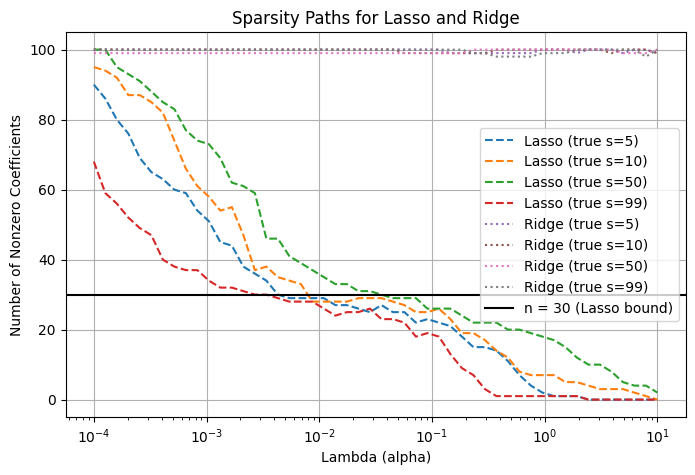

In [ ]:
sparsity_values = [5, 10, 50, 99]

lasso_results = {}
ridge_results = {}
alphas = np.logspace(-4, 1, 50)  # from 0.0001 to 10
for sparsity in sparsity_values:
    X_corr,y_corr,w_true_corr,support_corr,Sigma_corr= generate_correlated_sparse_linear_data(n=30, d=100, s=sparsity, sigma=1.0, signal=2.0, rho=0.2,random_seeds=20)
    lasso_nonzero = []
    ridge_nonzero = []
    for alpha in alphas:
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_corr, y_corr)

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_corr, y_corr)
    
        # count nonzero coefficients (choose 1e^-6 as threshold to account for numerical precision, assumes anything smaller is effectively zero)
        lasso_nonzero.append(np.sum(np.abs(lasso.coef_) > 1e-3))

        ridge_nonzero.append(np.sum(np.abs(ridge.coef_) > 1e-3))
    lasso_results[sparsity] = lasso_nonzero
    ridge_results[sparsity] = ridge_nonzero
    
plt.figure(figsize=(8, 5))
for sparsity, vals in lasso_results.items():
    plt.plot(alphas, vals, '--', label=f'Lasso (true s={sparsity})')
for sparsity, vals in ridge_results.items():
    plt.plot(alphas, vals, ':', label=f'Ridge (true s={sparsity})')

plt.axhline(y=30, color='k', linestyle='-', label=f'n = {30} (Lasso bound)')
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Number of Nonzero Coefficients')
plt.title('Sparsity Paths for Lasso and Ridge')
plt.legend()
plt.grid(True)
plt.show()
